In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df_to_train = pd.read_csv("../../data/dataset_training.csv", parse_dates=['InvoiceDate'])

2025-03-20 13:53:15.592379: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 13:53:17.065470: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 13:53:18.300184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742475199.284733    6496 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742475199.580594    6496 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742475201.997382    6496 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

- Enriquecemos los datos para ayudar al modelo

In [2]:
df_to_train['Month_sin'] = np.sin(2 * np.pi * df_to_train['Month'] / 12)
df_to_train['Month_cos'] = np.cos(2 * np.pi * df_to_train['Month'] / 12)
df_to_train['Day_sin'] = np.sin(2 * np.pi * df_to_train['Day'] / 12)
df_to_train['Day_cos'] = np.cos(2 * np.pi * df_to_train['Day'] / 12)

X_to_train = df_to_train[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']]
Y_to_train = df_to_train['TotalSales'].values.reshape(-1, 1)

# Normalizar los datos
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_to_train = scaler_X.fit_transform(X_to_train)
Y_to_train = scaler_Y.fit_transform(Y_to_train)

- Creamos la configuración de capas del modelo

In [5]:

# Crear el modelo
tf.random.set_seed(42)
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_to_train.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

- Entrenamos el modelo

In [8]:
# Entrenar el modelo
model.fit(X_to_train, Y_to_train, epochs=150, batch_size=32, verbose=0)

- Predecimos nuevos datos

In [9]:
df_to_test = pd.read_csv("../../data/dataset_prediction.csv", parse_dates=['InvoiceDate'])

df_to_test['Month_sin'] = np.sin(2 * np.pi * df_to_test['Month'] / 12)
df_to_test['Month_cos'] = np.cos(2 * np.pi * df_to_test['Month'] / 12)
df_to_test['Day_sin'] = np.sin(2 * np.pi * df_to_test['Day'] / 12)
df_to_test['Day_cos'] = np.cos(2 * np.pi * df_to_test['Day'] / 12)

X_to_test = df_to_test[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']]
Y_to_test = df_to_test['TotalSales'].values.reshape(-1, 1)

# Normalizar los datos de prueba
X_to_test = scaler_X.transform(X_to_test)
Y_to_test = scaler_Y.transform(Y_to_test)

# Hacer predicciones
predictions = model.predict(X_to_test)
predictions = scaler_Y.inverse_transform(predictions)
Y_to_test = scaler_Y.inverse_transform(Y_to_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


- Hacemos las métricas para evaluar el rendimiento

MAE: 8182.61
MSE: 98232627.56
RMSE: 9911.24


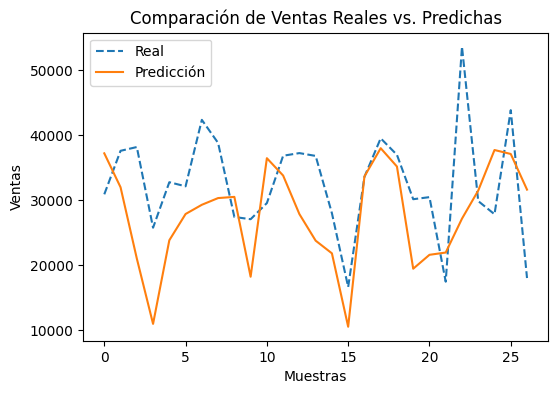

In [11]:
# Calcular métricas
mae = mean_absolute_error(Y_to_test, predictions)
mse = mean_squared_error(Y_to_test, predictions)
rmse = np.sqrt(mse)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Graficar resultados
plt.figure(figsize=(6, 4))
plt.plot(Y_to_test, label="Real", linestyle="dashed")
plt.plot(predictions, label="Predicción")
plt.legend()
plt.title("Comparación de Ventas Reales vs. Predichas")
plt.xlabel("Muestras")
plt.ylabel("Ventas")
plt.show()